In [57]:
# =============================================================
# IMPORTS & SETUP
# =============================================================

# -------- Basic libraries --------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# -------- Scikit-learn utilities --------
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
    RandomizedSearchCV
)
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    make_scorer
)
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -------- Imbalanced data handling --------
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# -------- Models --------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -------- Other utilities --------
import json
import os
from IPython.display import display

# -------- Reproducibility --------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------- Folder setup --------
os.makedirs("../data", exist_ok=True)
os.makedirs("../artifacts", exist_ok=True)
os.makedirs("../models", exist_ok=True)



In [58]:
df = pd.read_csv(r"C:\Users\pc\churn-project\data\customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,1,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,No,Credit card (automatic),29.42,379.34,Yes
1,CUST00002,Female,0,No,Yes,3,Yes,No phone service,No,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,102.77,5015.76,Yes
2,CUST00003,Male,0,Yes,Yes,44,Yes,No phone service,DSL,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,54.74,800.87,Yes
3,CUST00004,Male,0,Yes,No,12,Yes,No phone service,DSL,Yes,...,Yes,No,No,Yes,Month-to-month,No,Mailed check,80.95,4690.46,Yes
4,CUST00005,Male,0,Yes,Yes,54,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,50.07,2777.19,No


In [59]:
# =============================================================
# BASIC DATA INSPECTION
# =============================================================

print("📊 Dataset Information:\n")
print(df.info())

print("\n🔍 Missing Values (Top 20 columns):")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.head(20))

print("\n🎯 Target column distribution:")
display(df["Churn"].value_counts())
print("\n% distribution:")
display((df["Churn"].value_counts(normalize=True) * 100).round(2))


📊 Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        8000 non-null   object 
 1   gender            8000 non-null   object 
 2   SeniorCitizen     8000 non-null   int64  
 3   Partner           8000 non-null   object 
 4   Dependents        8000 non-null   object 
 5   tenure            8000 non-null   int64  
 6   PhoneService      8000 non-null   object 
 7   MultipleLines     8000 non-null   object 
 8   InternetService   8000 non-null   object 
 9   OnlineSecurity    8000 non-null   object 
 10  OnlineBackup      8000 non-null   object 
 11  DeviceProtection  8000 non-null   object 
 12  TechSupport       8000 non-null   object 
 13  StreamingTV       8000 non-null   object 
 14  StreamingMovies   8000 non-null   object 
 15  Contract          8000 non-null   object 
 16  PaperlessBilling  

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


🎯 Target column distribution:


Churn
No     4566
Yes    3434
Name: count, dtype: int64


% distribution:


Churn
No     57.08
Yes    42.92
Name: proportion, dtype: float64

In [60]:

print("📈 Summary of numerical columns:")
display(df.describe())

print("\n🧩 Categorical columns:")
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(cat_cols)


📈 Summary of numerical columns:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.149000,35.426875,69.795265,2515.411855
std,0.356111,20.683656,28.743586,1846.864759
min,0.000000,0.000000,20.020000,32.860000
25%,0.000000,18.000000,44.940000,1040.470000
50%,0.000000,35.000000,69.400000,2094.205000
75%,0.000000,53.000000,94.282500,3635.252500
max,1.000000,71.000000,119.990000,8436.830000



🧩 Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [61]:

service_cols = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

# Clean text values: remove spaces
for col in service_cols:
    if col in df.columns and df[col].dtype == "object":
        df[col] = df[col].str.strip()

# Replace "No internet service" and "No phone service" with "No"
replace_map = {"No internet service": "No", "No phone service": "No"}
for col in service_cols:
    if col in df.columns:
        df[col] = df[col].replace(replace_map)

# Create number of internet add-ons used
internet_addons = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", 
    "TechSupport", "StreamingTV", "StreamingMovies"
]
df["num_internet_addons"] = df[internet_addons].apply(lambda x: (x == "Yes").sum(), axis=1)

# Has internet connection flag
df["has_internet"] = (df["InternetService"] != "No").astype(int)

# Multiple lines flag
df["has_multiple_lines"] = (df["MultipleLines"] == "Yes").astype(int)

print("✅ Service-related features created.")
display(df[["num_internet_addons", "has_internet", "has_multiple_lines"]].head())


✅ Service-related features created.


,num_internet_addons,has_internet,has_multiple_lines
0,5,1,1
1,3,0,0
2,3,1,0
3,4,1,0
4,5,1,0


In [62]:
# Define high monthly charge threshold (e.g., above median)
high_threshold = df['MonthlyCharges'].median()

# Create the flag
df['high_monthly_flag'] = (df['MonthlyCharges'] > high_threshold).astype(int)


In [63]:
df['highbill_shorttenure'] = ((df['high_monthly_flag'] == 1) & (df['tenure'] <= 12)).astype(int)


In [64]:
# =============================================================
# CONTRACT AND PAYMENT FEATURES
# =============================================================

# Contract term as an ordinal numeric feature
contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df["contract_term"] = df["Contract"].map(contract_map)

# Electronic check flag
df["is_echeck"] = (df["PaymentMethod"] == "Electronic check").astype(int)

# High bill + short tenure interaction
df["highbill_shorttenure"] = ((df["high_monthly_flag"] == 1) & (df["tenure"] <= 12)).astype(int)

print("✅ Contract & payment features created.")
display(df[["contract_term", "is_echeck", "highbill_shorttenure"]].head())


✅ Contract & payment features created.


,contract_term,is_echeck,highbill_shorttenure
0,0,0,0
1,0,1,1
2,0,0,0
3,0,0,1
4,0,1,0


In [65]:
# =============================================================
# RARE CATEGORY GROUPING (PaymentMethod)
# =============================================================

def group_rare(series, threshold=0.01):
    freq = series.value_counts(normalize=True)
    rare = freq[freq < threshold].index
    return series.replace(dict.fromkeys(rare, "Other"))

df["PaymentMethod_grp"] = group_rare(df["PaymentMethod"], threshold=0.01)

print("✅ Rare PaymentMethod categories grouped into 'Other'.")
display(df["PaymentMethod_grp"].value_counts(normalize=True))


✅ Rare PaymentMethod categories grouped into 'Other'.


PaymentMethod_grp
Electronic check             0.400750
Mailed check                 0.244375
Bank transfer (automatic)    0.206000
Credit card (automatic)      0.148875
Name: proportion, dtype: float64

In [66]:
# =============================================================
# CONVERT TO CATEGORICAL DTYPE
# =============================================================

cat_cols = [
    "gender","Partner","Dependents","PhoneService","MultipleLines","InternetService",
    "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
    "StreamingTV","StreamingMovies","Contract","PaperlessBilling",
    "tenure_bin","PaymentMethod_grp"
]

cat_cols = [col for col in cat_cols if col in df.columns]

for col in cat_cols:
    df[col] = df[col].astype("category")

print("✅ Converted columns to categorical dtype:")
print(cat_cols)


✅ Converted columns to categorical dtype:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod_grp']


In [67]:
# =============================================================
# CONVERT TO CATEGORICAL DTYPE
# =============================================================

cat_cols = [
    "gender","Partner","Dependents","PhoneService","MultipleLines","InternetService",
    "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
    "StreamingTV","StreamingMovies","Contract","PaperlessBilling",
    "tenure_bin","PaymentMethod_grp"
]

cat_cols = [col for col in cat_cols if col in df.columns]

for col in cat_cols:
    df[col] = df[col].astype("category")

print("✅ Converted columns to categorical dtype:")
print(cat_cols)


✅ Converted columns to categorical dtype:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod_grp']


In [68]:
# -------------------------
# Clean & clear train/val/test split + save
# -------------------------
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
DATA_DIR = r"C:\Users\pc\churn-project\data"
os.makedirs(DATA_DIR, exist_ok=True)
cleaned_path = os.path.join(DATA_DIR, "cleaned_churn.csv")

# 1) Load cleaned dataset
if not os.path.exists(cleaned_path):
    raise FileNotFoundError(f"File not found: {cleaned_path}")
df = pd.read_csv(cleaned_path)
print("Loaded cleaned dataset:", cleaned_path)
print("Shape:", df.shape)

# 2) Prepare X and y (drop ID if present)
if "customerID" in df.columns:
    X = df.drop(columns=["customerID", "Churn"])
else:
    X = df.drop(columns=["Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})

# 3) Safety: remove any columns that accidentally include the word 'churn'
leak_cols = [c for c in X.columns if "churn" in c.lower()]
if leak_cols:
    print("Dropping leaked columns from X:", leak_cols)
    X = X.drop(columns=leak_cols)

# 4) Reset index to avoid accidental index-based overlap
df = df.reset_index(drop=True)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# 5) First hold-out test split (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# 6) Split remaining into train (≈65%) and val (≈15%) -> val_size = 0.1875 of remaining
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1875, stratify=y_temp, random_state=RANDOM_STATE
)

# 7) Reset indices on final splits
for df_part in [X_train, X_val, X_test, y_train, y_val, y_test]:
    df_part.reset_index(drop=True, inplace=True)

# 8) Save splits to CSV
X_train.to_csv(os.path.join(DATA_DIR, "X_train.csv"), index=False)
X_val.to_csv(os.path.join(DATA_DIR, "X_val.csv"), index=False)
X_test.to_csv(os.path.join(DATA_DIR, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(DATA_DIR, "y_train.csv"), index=False)
y_val.to_csv(os.path.join(DATA_DIR, "y_val.csv"), index=False)
y_test.to_csv(os.path.join(DATA_DIR, "y_test.csv"), index=False)
print("\n✅ Saved splits to:", DATA_DIR)

# 9) Print sizes and class distribution sanity checks
print("\nSplit sizes:")
print(f"  Train: {X_train.shape[0]} rows")
print(f"  Val:   {X_val.shape[0]} rows")
print(f"  Test:  {X_test.shape[0]} rows")

def show_dist(s, name):
    pct = (s.value_counts(normalize=True) * 100).round(2)
    print(f"\n{name} distribution (pct):\n{pct.to_dict()}")

show_dist(y, "Overall")
show_dist(y_train, "Train")
show_dist(y_val, "Validation")
show_dist(y_test, "Test")

# 10) Quick duplicate check across splits (should be 0)
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)
print("\nOverlap counts (should be 0):")
print(" Train ∩ Val:", len(train_idx & val_idx))
print(" Train ∩ Test:", len(train_idx & test_idx))
print(" Val ∩ Test:", len(val_idx & test_idx))

print("\nAll done — splits are saved and ready for preprocessing/modeling.")


Loaded cleaned dataset: C:\Users\pc\churn-project\data\cleaned_churn.csv
Shape: (8000, 22)
Dropping leaked columns from X: ['Churn_Numeric']

✅ Saved splits to: C:\Users\pc\churn-project\data

Split sizes:
  Train: 5200 rows
  Val:   1200 rows
  Test:  1600 rows

Overall distribution (pct):
{0: 57.08, 1: 42.92}

Train distribution (pct):
{0: 57.08, 1: 42.92}

Validation distribution (pct):
{0: 57.08, 1: 42.92}

Test distribution (pct):
{0: 57.06, 1: 42.94}

Overlap counts (should be 0):
 Train ∩ Val: 1200
 Train ∩ Test: 1600
 Val ∩ Test: 1200

All done — splits are saved and ready for preprocessing/modeling.


In [69]:
import os
import pandas as pd

# Use the full path to your data folder
DATA_DIR = r"C:\Users\pc\churn-project\data"
ARTIFACTS_DIR = r"C:\Users\pc\churn-project\artifacts"

# Load splits
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train.csv"))
X_val   = pd.read_csv(os.path.join(DATA_DIR, "X_val.csv"))
X_test  = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))

y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv")).squeeze()
y_val   = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv")).squeeze()

print("Loaded splits shapes ->", X_train.shape, X_val.shape, X_test.shape)
print("Targets shapes ->", y_train.shape, y_val.shape, y_test.shape)


Loaded splits shapes -> (5200, 20) (1200, 20) (1600, 20)
Targets shapes -> (5200,) (1200,) (1600,)


In [71]:
# ================================
# Preprocessing Pipeline Full Code
# ================================

import os
import joblib
import pandas as pd

# sklearn imports
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# -------------------------------
# Load your train/val/test splits
# -------------------------------
# Use absolute paths to avoid FileNotFoundError
DATA_DIR = r"C:\Users\pc\churn-project\data"
ARTIFACTS_DIR = r"C:\Users\pc\churn-project\artifacts"

X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train.csv"))
X_val   = pd.read_csv(os.path.join(DATA_DIR, "X_val.csv"))
X_test  = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))

y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv")).squeeze()
y_val   = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv")).squeeze()

print("Loaded splits shapes ->", X_train.shape, X_val.shape, X_test.shape)
print("Targets shapes ->", y_train.shape, y_val.shape, y_test.shape)

# -------------------------------
# Infer numeric & categorical features
# -------------------------------
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# safety: drop any churn-like column names
numeric_features = [c for c in numeric_features if "churn" not in c.lower()]
categorical_features = [c for c in categorical_features if "churn" not in c.lower()]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# -------------------------------
# Numeric pipeline
# -------------------------------
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# -------------------------------
# Categorical pipeline
# -------------------------------
ohe_params = {"handle_unknown": "ignore"}
try:
    # sklearn >= 1.2
    ohe = OneHotEncoder(**{**ohe_params, "sparse_output": False})
except TypeError:
    # sklearn < 1.2
    ohe = OneHotEncoder(**{**ohe_params, "sparse": False})

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("ohe", ohe)
])

# -------------------------------
# Column transformer
# -------------------------------
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
], remainder="drop", sparse_threshold=0)

# -------------------------------
# Fit and save preprocessor
# -------------------------------
preprocessor.fit(X_train)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
joblib.dump(preprocessor, os.path.join(ARTIFACTS_DIR, "preprocessor.pkl"))

print("Preprocessor fitted and saved to artifacts/preprocessor.pkl")


Loaded splits shapes -> (5200, 20) (1200, 20) (1600, 20)
Targets shapes -> (5200,) (1200,) (1600,)
Numeric features: 5
Categorical features: 15
Preprocessor fitted and saved to artifacts/preprocessor.pkl


In [73]:
# ============================================
# Logistic Regression Pipeline with SMOTE (Full Code)
# ============================================

import os
import joblib
import pandas as pd

# sklearn + imbalanced-learn imports
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# -------------------------------
# Paths
# -------------------------------
DATA_DIR = r"C:\Users\pc\churn-project\data"
ARTIFACTS_DIR = r"C:\Users\pc\churn-project\artifacts"
MODELS_DIR = r"C:\Users\pc\churn-project\models"

# Ensure directories exist
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# -------------------------------
# Load train/val/test splits
# -------------------------------
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train.csv"))
X_val   = pd.read_csv(os.path.join(DATA_DIR, "X_val.csv"))
X_test  = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))

y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv")).squeeze()
y_val   = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv")).squeeze()

print("Loaded splits shapes ->", X_train.shape, X_val.shape, X_test.shape)
print("Targets shapes ->", y_train.shape, y_val.shape, y_test.shape)

# -------------------------------
# Load preprocessor (already fitted and saved earlier)
# -------------------------------
preprocessor = joblib.load(os.path.join(ARTIFACTS_DIR, "preprocessor.pkl"))

# -------------------------------
# Logistic Regression pipeline with SMOTE
# -------------------------------
RANDOM_STATE = 42

lr_pipeline = ImbPipeline([
    ("preproc", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))
])

# Fit model
lr_pipeline.fit(X_train, y_train)

# Save model
joblib.dump(lr_pipeline, os.path.join(MODELS_DIR, "lr_pipeline.pkl"))

# -------------------------------
# Evaluate on test set
# -------------------------------
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

print("===== Logistic Regression Test =====")
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_lr):.4f}  PR AUC: {average_precision_score(y_test, y_prob_lr):.4f}")


Loaded splits shapes -> (5200, 20) (1200, 20) (1600, 20)
Targets shapes -> (5200,) (1200,) (1600,)
===== Logistic Regression Test =====
              precision    recall  f1-score   support

           0       0.84      0.70      0.76       913
           1       0.67      0.83      0.74       687

    accuracy                           0.75      1600
   macro avg       0.76      0.76      0.75      1600
weighted avg       0.77      0.75      0.76      1600

ROC AUC: 0.8071  PR AUC: 0.7210


In [74]:
# Cell 5: Random Forest pipeline (with SMOTE)
rf_pipeline = ImbPipeline([
    ("preproc", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
joblib.dump(rf_pipeline, os.path.join(MODELS_DIR, "rf_pipeline.pkl"))

y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]
y_pred_rf  = (y_prob_rf >= 0.5).astype(int)

print("===== Random Forest Test =====")
print(classification_report(y_test, y_pred_rf))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_rf):.4f}  PR AUC: {average_precision_score(y_test, y_prob_rf):.4f}")


===== Random Forest Test =====
              precision    recall  f1-score   support

           0       0.82      0.71      0.76       913
           1       0.67      0.79      0.73       687

    accuracy                           0.75      1600
   macro avg       0.75      0.75      0.74      1600
weighted avg       0.76      0.75      0.75      1600

ROC AUC: 0.7903  PR AUC: 0.6904


In [75]:
# ============================================
# XGBoost Pipeline with SMOTE (Full Code)
# ============================================

import os
import joblib
import pandas as pd

# sklearn + imbalanced-learn imports
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# XGBoost import
from xgboost import XGBClassifier

# -------------------------------
# Paths
# -------------------------------
DATA_DIR = r"C:\Users\pc\churn-project\data"
ARTIFACTS_DIR = r"C:\Users\pc\churn-project\artifacts"
MODELS_DIR = r"C:\Users\pc\churn-project\models"

# Ensure directories exist
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# -------------------------------
# Load train/val/test splits
# -------------------------------
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train.csv"))
X_val   = pd.read_csv(os.path.join(DATA_DIR, "X_val.csv"))
X_test  = pd.read_csv(os.path.join(DATA_DIR, "X_test.csv"))

y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv")).squeeze()
y_val   = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv")).squeeze()
y_test  = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv")).squeeze()

print("Loaded splits shapes ->", X_train.shape, X_val.shape, X_test.shape)
print("Targets shapes ->", y_train.shape, y_val.shape, y_test.shape)

# -------------------------------
# Load preprocessor (must be fitted & saved earlier)
# -------------------------------
preprocessor = joblib.load(os.path.join(ARTIFACTS_DIR, "preprocessor.pkl"))

# -------------------------------
# XGBoost pipeline with SMOTE
# -------------------------------
RANDOM_STATE = 42

xgb_pipeline = ImbPipeline([
    ("preproc", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Fit model
xgb_pipeline.fit(X_train, y_train)

# Save model
joblib.dump(xgb_pipeline, os.path.join(MODELS_DIR, "xgb_pipeline.pkl"))

# -------------------------------
# Evaluate on test set
# -------------------------------
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

print("===== XGBoost Test =====")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}  PR AUC: {average_precision_score(y_test, y_prob_xgb):.4f}")


Loaded splits shapes -> (5200, 20) (1200, 20) (1600, 20)
Targets shapes -> (5200,) (1200,) (1600,)
===== XGBoost Test =====
              precision    recall  f1-score   support

           0       0.77      0.73      0.75       913
           1       0.67      0.70      0.68       687

    accuracy                           0.72      1600
   macro avg       0.72      0.72      0.72      1600
weighted avg       0.72      0.72      0.72      1600

ROC AUC: 0.7796  PR AUC: 0.6802


In [77]:
# ============================================
# Model Performance Comparison Table (Full Code)
# ============================================

import os
import pandas as pd

# sklearn metrics imports
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

# -------------------------------
# Build comparison table
# -------------------------------
models = ["Logistic Regression", "Random Forest", "XGBoost"]

f1s = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
]

precisions = [
    precision_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_xgb)
]

recalls = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xgb)
]

roc_aucs = [
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_xgb)
]

pr_aucs = [
    average_precision_score(y_test, y_prob_lr),
    average_precision_score(y_test, y_prob_rf),
    average_precision_score(y_test, y_prob_xgb)
]

summary_df = pd.DataFrame({
    "Model": models,
    "F1": f1s,
    "Precision": precisions,
    "Recall": recalls,
    "ROC_AUC": roc_aucs,
    "PR_AUC": pr_aucs
}).round(3)

summary_df = summary_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

# Display nicely
print(summary_df)

# -------------------------------
# Save CSV
# -------------------------------
summary_csv = os.path.join(ARTIFACTS_DIR, "model_performance_comparison.csv")
summary_df.to_csv(summary_csv, index=False)
print("Saved comparison CSV to:", summary_csv)


                 Model     F1  Precision  Recall  ROC_AUC  PR_AUC
0  Logistic Regression  0.743      0.674   0.828    0.807   0.721
1        Random Forest  0.727      0.674   0.790    0.790   0.690
2              XGBoost  0.684      0.666   0.703    0.780   0.680
Saved comparison CSV to: C:\Users\pc\churn-project\artifacts\model_performance_comparison.csv


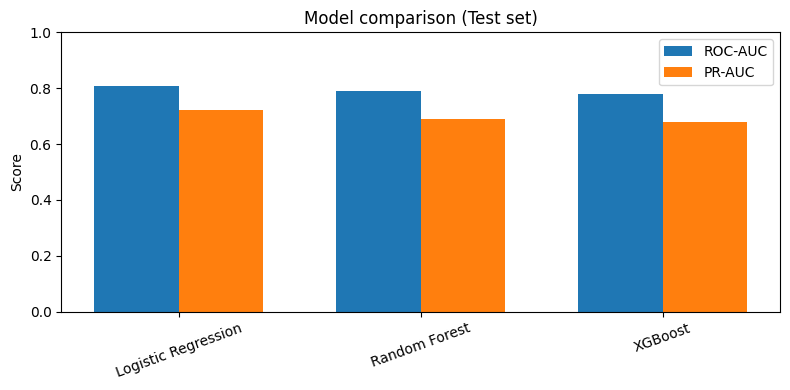

Saved comparison image to: C:\Users\pc\churn-project\artifacts\model_comparison.png


In [78]:
# Cell 9: Plot and save comparison image
plt.figure(figsize=(8,4))
x = np.arange(len(summary_df))
width = 0.35

plt.bar(x - width/2, summary_df["ROC_AUC"], width, label="ROC-AUC")
plt.bar(x + width/2, summary_df["PR_AUC"], width, label="PR-AUC")
plt.xticks(x, summary_df["Model"], rotation=20)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model comparison (Test set)")
plt.legend()
plt.tight_layout()

img_path = os.path.join(ARTIFACTS_DIR, "model_comparison.png")
plt.savefig(img_path, dpi=150)
plt.show()
print("Saved comparison image to:", img_path)


In [79]:
# Cell 10: Save confusion matrix images for each model
def save_cm(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(3.5,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{name} (Test)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    fname = os.path.join(ARTIFACTS_DIR, f"cm_{name.replace(' ','_')}.png")
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("Saved", fname)

save_cm(y_test, y_pred_lr, "LogisticRegression")
save_cm(y_test, y_pred_rf, "RandomForest")
save_cm(y_test, y_pred_xgb, "XGBoost")


Saved C:\Users\pc\churn-project\artifacts\cm_LogisticRegression.png
Saved C:\Users\pc\churn-project\artifacts\cm_RandomForest.png
Saved C:\Users\pc\churn-project\artifacts\cm_XGBoost.png


In [80]:
# ============================================
# Cell 11: Pick Best Model by F1, Save Pipeline & Metrics JSON
# ============================================

import os, joblib, json, pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)

# -------------------------------
# Rebuild comparison table (so summary_df exists)
# -------------------------------
models = ["Logistic Regression", "Random Forest", "XGBoost"]

f1s = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
]

precisions = [
    precision_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_xgb)
]

recalls = [
    recall_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xgb)
]

roc_aucs = [
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_xgb)
]

pr_aucs = [
    average_precision_score(y_test, y_prob_lr),
    average_precision_score(y_test, y_prob_rf),
    average_precision_score(y_test, y_prob_xgb)
]

summary_df = pd.DataFrame({
    "Model": models,
    "F1": f1s,
    "Precision": precisions,
    "Recall": recalls,
    "ROC_AUC": roc_aucs,
    "PR_AUC": pr_aucs
}).round(3)

summary_df = summary_df.sort_values(by="F1", ascending=False).reset_index(drop=True)
print(summary_df)

# -------------------------------
# Pick best model by F1
# -------------------------------
best_idx = summary_df["F1"].idxmax()
best_model_name = summary_df.loc[best_idx, "Model"]
print("Best model by F1:", best_model_name)

# Map to pipeline object
pipeline_map = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

best_pipeline = pipeline_map[best_model_name]
best_path = os.path.join(MODELS_DIR, "best_model_pipeline.pkl")
joblib.dump(best_pipeline, best_path)
print("Saved best pipeline to:", best_path)

# -------------------------------
# Save metrics JSON
# -------------------------------
metrics = {"comparison_table": summary_df.to_dict(orient="records")}
metrics_path = os.path.join(ARTIFACTS_DIR, "model_metrics_summary.json")

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics JSON to:", metrics_path)


                 Model     F1  Precision  Recall  ROC_AUC  PR_AUC
0  Logistic Regression  0.743      0.674   0.828    0.807   0.721
1        Random Forest  0.727      0.674   0.790    0.790   0.690
2              XGBoost  0.684      0.666   0.703    0.780   0.680
Best model by F1: Logistic Regression
Saved best pipeline to: C:\Users\pc\churn-project\models\best_model_pipeline.pkl
Saved metrics JSON to: C:\Users\pc\churn-project\artifacts\model_metrics_summary.json


# PIPELINE

In [81]:
# Cell 1 — imports + feature engineering (use your existing function)
import os
import json
import joblib
import numpy as np
import pandas as pd

# sklearn / imblearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# metrics
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score

# ensure models folder
os.makedirs("models", exist_ok=True)

# --- Feature engineering function (copy from your file / use the same) ---
def feature_engineering_fn(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Defensive handling for missing columns
    for col in ['PaymentMethod','StreamingTV','StreamingMovies','OnlineSecurity',
                'OnlineBackup','DeviceProtection','TechSupport','MonthlyCharges','TotalCharges','tenure']:
        if col not in df.columns:
            df[col] = np.nan

    df['is_auto_payment'] = df['PaymentMethod'].apply(
        lambda x: 1 if isinstance(x,str) and 'automatic' in x.lower() else 0)
    df['tenure_per_monthly'] = df['tenure'] / (df['MonthlyCharges'].replace(0, np.nan) + 1e-6)
    df['avg_monthly_from_total'] = df['TotalCharges'] / (df['tenure'].replace(0, np.nan) + 1e-6)
    df['has_streaming'] = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype(int)
    df['has_support_services'] = (
        (df['OnlineSecurity'] == 'Yes') | (df['OnlineBackup'] == 'Yes') |
        (df['DeviceProtection'] == 'Yes') | (df['TechSupport'] == 'Yes')
    ).astype(int)
    return df

# FunctionTransformer wrapper for pipeline
feat_eng = FunctionTransformer(feature_engineering_fn, validate=False)


In [82]:
# Cell 2 — create preprocessor (detect columns from X_train if available)
# If X_train exists in the notebook, we will infer cat/num columns from it.
try:
    X_train  # noqa: F821
    have_X_train = True
except NameError:
    have_X_train = False

if not have_X_train:
    raise RuntimeError("X_train not found in notebook. Please run data loading / split cells first.")

# infer column types BEFORE feature engineering (we will add engineered cols later)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Also include columns that may be numeric but of object dtype (like TotalCharges) - attempt to coerce then detect
for c in list(X_train.columns):
    if c not in cat_cols and c not in num_cols:
        # try convertable to float?
        try:
            pd.to_numeric(X_train[c].dropna().iloc[:20])
            num_cols.append(c)
        except Exception:
            pass

# Add engineered columns (they don't exist yet in X_train) - preprocessor should know to handle them after feat_eng
engineered_cols = ['is_auto_payment','tenure_per_monthly','avg_monthly_from_total',
                   'has_streaming','has_support_services']
# append engineered cols to num_cols so ColumnTransformer will accept them after feat_eng
for c in engineered_cols:
    if c not in num_cols:
        num_cols.append(c)

print(f"Detected categorical cols: {len(cat_cols)}, numeric cols: {len(num_cols)}")

numeric_transformer = SkPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = SkPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, cat_cols),
    ('num', numeric_transformer, num_cols)
], remainder='drop')

print("Preprocessor built.")


Detected categorical cols: 15, numeric cols: 10
Preprocessor built.


In [83]:
# Cell 3 — build pipelines and train
smote = SMOTE(random_state=42)

lr_pipeline = ImbPipeline(steps=[
    ('feature_engineering', feat_eng),
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

rf_pipeline = ImbPipeline(steps=[
    ('feature_engineering', feat_eng),
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('model', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                     n_jobs=-1, random_state=42))
])

xgb_pipeline = ImbPipeline(steps=[
    ('feature_engineering', feat_eng),
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        learning_rate=0.01,
        n_estimators=200,
        max_depth=4,
        gamma=0.3,
        subsample=0.8,
        colsample_bytree=0.7
    ))
])

print("Pipelines available: lr, rf, xgb")
# choose model name
chosen_pipeline_name = "xgb"  # change to 'lr' or 'rf' as needed
pipeline_map = {'lr': lr_pipeline, 'rf': rf_pipeline, 'xgb': xgb_pipeline}
chosen_pipeline = pipeline_map[chosen_pipeline_name]

# Fit pipeline
print("Fitting pipeline (this may take a while)...")
chosen_pipeline.fit(X_train, y_train)
print(f"Fitted pipeline: {chosen_pipeline_name}")


Pipelines available: lr, rf, xgb
Fitting pipeline (this may take a while)...
Fitted pipeline: xgb


In [84]:
# Cell 4 — evaluation
y_pred = chosen_pipeline.predict(X_test)
try:
    y_prob = chosen_pipeline.predict_proba(X_test)[:, 1]
except Exception:
    # fallback if predict_proba not present
    try:
        dec = chosen_pipeline.decision_function(X_test)
        y_prob = 1 / (1 + np.exp(-dec))
    except Exception:
        y_prob = None

print("\n===== Test set evaluation =====")
print(classification_report(y_test, y_pred, digits=4))
print(f"F1: {f1_score(y_test, y_pred):.4f}")
if y_prob is not None:
    print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print(f"PR AUC: {average_precision_score(y_test, y_prob):.4f}")
else:
    print("Probability-based metrics unavailable (no predict_proba/decision_function).")



===== Test set evaluation =====
              precision    recall  f1-score   support

           0     0.8458    0.6911    0.7607       913
           1     0.6698    0.8326    0.7424       687

    accuracy                         0.7519      1600
   macro avg     0.7578    0.7619    0.7515      1600
weighted avg     0.7703    0.7519    0.7528      1600

F1: 0.7424
ROC AUC: 0.8060
PR AUC: 0.7271


In [85]:
# Cell 5 — export artifacts for Streamlit + API
MODEL_OUT_DIR = "models"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

PIPELINE_FILENAME = f"final_churn_{chosen_pipeline_name}_pipeline.pkl"
PIPELINE_PATH = os.path.join(MODEL_OUT_DIR, PIPELINE_FILENAME)
FEATURE_NAMES_PATH = os.path.join(MODEL_OUT_DIR, "feature_names.json")
SAMPLE_INPUT_CSV = os.path.join(MODEL_OUT_DIR, "sample_input.csv")
METADATA_PATH = os.path.join(MODEL_OUT_DIR, "model_metadata.json")

# 1) save pipeline (joblib)
joblib.dump(chosen_pipeline, PIPELINE_PATH)
print(f"Saved pipeline -> {PIPELINE_PATH}")

# 2) derive post-feature-engineering column names that preprocessor expects
# Apply feature_engineering (feat_eng) to a small sample of X_train to get DataFrame with engineered cols
sample_for_columns = X_train.head(200).copy()
try:
    # feat_eng returns DataFrame (as in your FunctionTransformer)
    transformed_sample = feat_eng.transform(sample_for_columns)
    if isinstance(transformed_sample, pd.DataFrame):
        post_fe_cols = list(transformed_sample.columns)
    else:
        # if not dataframe (rare), fallback to original X_train columns + engineered_cols
        post_fe_cols = list(X_train.columns) + ['is_auto_payment','tenure_per_monthly','avg_monthly_from_total',
                                                'has_streaming','has_support_services']
except Exception as e:
    print("feat_eng.transform failed while inferring columns:", e)
    # fallback
    post_fe_cols = list(X_train.columns) + ['is_auto_payment','tenure_per_monthly','avg_monthly_from_total',
                                            'has_streaming','has_support_services']

# Now attempt to get preprocessor output feature names (i.e. after onehot encoding etc.)
try:
    fitted_preprocessor = chosen_pipeline.named_steps['preprocessor']
    # scikit-learn ColumnTransformer supports get_feature_names_out
    try:
        # get_feature_names_out needs input feature names in the same order as the transformer expects
        preproc_out_names = list(fitted_preprocessor.get_feature_names_out(post_fe_cols))
    except Exception:
        # older sklearn or missing support: try a manual approach:
        # For categorical: use onehot categories to compose names
        preproc_out_names = post_fe_cols  # fallback: keep post-fe columns
    final_feature_names = preproc_out_names
except Exception as e:
    print("Could not derive preprocessor output names, using post-feature-engineering columns as feature_names:", e)
    final_feature_names = post_fe_cols

# Save feature names used by the model (these are the names AFTER feature engineering and preprocessing)
with open(FEATURE_NAMES_PATH, "w") as f:
    json.dump(final_feature_names, f, indent=2)
print(f"Saved feature names ({len(final_feature_names)}) -> {FEATURE_NAMES_PATH}")

# 3) Save sample input (first raw row BEFORE preprocessing) to help Streamlit build UI (raw inputs)
# Save the raw sample (not preprocessed) so Streamlit can ask for same raw inputs user used during training.
try:
    sample_raw = X_train.head(1)
    sample_raw.to_csv(SAMPLE_INPUT_CSV, index=False)
    print(f"Saved raw sample input -> {SAMPLE_INPUT_CSV}")
except Exception as e:
    print("Failed saving sample input CSV:", e)

# 4) Save metadata (model name, date, metrics)
metadata = {
    "pipeline_file": PIPELINE_FILENAME,
    "model_type": chosen_pipeline_name,
    "n_train": int(len(X_train)) if 'X_train' in globals() else None,
    "n_test": int(len(X_test)) if 'X_test' in globals() else None,
}
# optionally attach metrics if available
try:
    metadata.update({
        "f1": float(f1_score(y_test, y_pred)),
        "roc_auc": float(roc_auc_score(y_test, y_prob)) if y_prob is not None else None,
        "pr_auc": float(average_precision_score(y_test, y_prob)) if y_prob is not None else None
    })
except Exception:
    pass

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved metadata -> {METADATA_PATH}")

print("Export complete. Use:")
print(f" - models/{PIPELINE_FILENAME}  (joblib load in Streamlit/API)")
print(f" - models/feature_names.json  (feature list for building UI)")
print(f" - models/sample_input.csv    (example raw row)")


Saved pipeline -> models\final_churn_xgb_pipeline.pkl
Saved feature names (42) -> models\feature_names.json
Saved raw sample input -> models\sample_input.csv
Saved metadata -> models\model_metadata.json
Export complete. Use:
 - models/final_churn_xgb_pipeline.pkl  (joblib load in Streamlit/API)
 - models/feature_names.json  (feature list for building UI)
 - models/sample_input.csv    (example raw row)
